# Robbins-Monro SVM — Province vs Region comparison

This notebook tunes and evaluates the Robbins-Monro SVM optimizer under two
feature setups:

| Model | Categorical feature |
|-------|---------------------|
| **Original** | `Province / Territory` (13 one-hot columns) |
| **Region** | `region` (6 one-hot columns: Atlantic, Quebec, Ontario, Prairies, BC, Territories) |

All numeric features, transformations, CV folds, and optimizer hyperparameter
grids are identical between the two setups.

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

from cv_tuning import (
    prepare_train_test_data,
    prepare_train_test_data_region,
    CV_FOLDS,
)
from optimizers import (
    robbins_monro_svm,
    predict_rm,
    tune_optimizer_joint_cv,
    fit_best,
    RM_PARAM_GRID,
    print_eval_report,
    best_per_kernel,
)

## 2. Load data — original and region variants

In [2]:
FILEPATH = '../data/ridings.csv'

data_orig   = prepare_train_test_data(filepath=FILEPATH)
data_region = prepare_train_test_data_region(filepath=FILEPATH)

print('Original  — X_train shape:', data_orig['X_train_proc'].shape)
print('Region    — X_train shape:', data_region['X_train_proc'].shape)

Original  — X_train shape: (273, 20)
Region    — X_train shape: (273, 14)


## 3. Hyperparameter search (10-fold CV)



In [3]:
from kernels import KERNEL_REGISTRY

n_kernels = sum(len(v['param_grid']) for v in KERNEL_REGISTRY.values())
print(f'RM param grid size : {len(RM_PARAM_GRID)} optimizer combos')
print(f'Kernel combos      : {n_kernels}')
print(f'Total configs      : {n_kernels * len(RM_PARAM_GRID)} × 10 folds')

RM param grid size : 36 optimizer combos
Kernel combos      : 42
Total configs      : 1512 × 10 folds


### 3a. Tune — Original (Province / Territory)

In [4]:
search_orig = tune_optimizer_joint_cv(
    robbins_monro_svm,
    data_orig['X_train_proc'],
    data_orig['y_train'],
    param_grid=RM_PARAM_GRID,
    verbose=True,
)

print('\nBest CV score (original):', round(search_orig['best_result']['mean_cv'], 4))
print('Best config  (original):', {
    k: v for k, v in search_orig['best_result'].items()
    if k not in {'mean_cv', 'std_cv', 'kernel_params'}
})

  linear    combos tested:   36  best_cv so far: 0.7913  [20s]
  rbf       combos tested:  216  best_cv so far: 0.8243  [125s]
  poly      combos tested: 1188  best_cv so far: 0.8351  [674s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8351  [871s]

Best CV score (original): 0.8351
Best config  (original): {'kernel': 'poly', 'lambda_reg': 0.001, 'eta0': 0.01, 'decay': 0.01, 'n_epochs': 50}


### 3b. Tune — Region

In [5]:
search_region = tune_optimizer_joint_cv(
    robbins_monro_svm,
    data_region['X_train_proc'],
    data_region['y_train'],
    param_grid=RM_PARAM_GRID,
    verbose=True,
)

print('\nBest CV score (region):', round(search_region['best_result']['mean_cv'], 4))
print('Best config  (region):', {
    k: v for k, v in search_region['best_result'].items()
    if k not in {'mean_cv', 'std_cv', 'kernel_params'}
})

  linear    combos tested:   36  best_cv so far: 0.7874  [20s]
  rbf       combos tested:  216  best_cv so far: 0.8246  [128s]
  poly      combos tested: 1188  best_cv so far: 0.8246  [699s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8246  [902s]

Best CV score (region): 0.8246
Best config  (region): {'kernel': 'rbf', 'lambda_reg': 0.001, 'eta0': 0.1, 'decay': 0.1, 'n_epochs': 50}


## 4. Refit on full training set with best config

In [6]:
N_EPOCHS_FINAL = 150

fit_orig = fit_best(
    robbins_monro_svm,
    data_orig['X_train_proc'],  data_orig['y_train_svm'],
    data_orig['X_test_proc'],   data_orig['y_test_svm'],
    best_result=search_orig['best_result'],
    n_epochs_override=N_EPOCHS_FINAL,
)

fit_region = fit_best(
    robbins_monro_svm,
    data_region['X_train_proc'], data_region['y_train_svm'],
    data_region['X_test_proc'],  data_region['y_test_svm'],
    best_result=search_region['best_result'],
    n_epochs_override=N_EPOCHS_FINAL,
)

y_pred_orig   = predict_rm(fit_orig,   data_orig['X_test_proc'])
y_pred_region = predict_rm(fit_region, data_region['X_test_proc'])

acc_orig   = accuracy_score(data_orig['y_test'],   y_pred_orig)
acc_region = accuracy_score(data_region['y_test'], y_pred_region)

print(f'Test accuracy — Original : {acc_orig:.4f}')
print(f'Test accuracy — Region   : {acc_region:.4f}')

Test accuracy — Original : 0.8551
Test accuracy — Region   : 0.8696


## 5. Classification reports

In [7]:
print_eval_report(data_orig['y_test'], y_pred_orig,
                     model_name='RM SVM — Original (Province / Territory)')

=== RM SVM — Original (Province / Territory) ===
Test Accuracy : 0.8551

--- Descriptive Statistics (per-sample correctness) ---
  Mean   : 0.8551
  Std    : 0.3520
  Median : 1.0000
  Q1     : 1.0000
  Q3     : 1.0000
  Min    : 0.0000
  Max    : 1.0000

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.94      0.87        35
           1       0.93      0.76      0.84        34

    accuracy                           0.86        69
   macro avg       0.87      0.85      0.85        69
weighted avg       0.87      0.86      0.85        69

--- Confusion Matrix ---
[[33  2]
 [ 8 26]]



In [8]:
print_eval_report(data_region['y_test'], y_pred_region,
                     model_name='RM SVM — Region')

=== RM SVM — Region ===
Test Accuracy : 0.8696

--- Descriptive Statistics (per-sample correctness) ---
  Mean   : 0.8696
  Std    : 0.3368
  Median : 1.0000
  Q1     : 1.0000
  Q3     : 1.0000
  Min    : 0.0000
  Max    : 1.0000

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        35
           1       0.86      0.88      0.87        34

    accuracy                           0.87        69
   macro avg       0.87      0.87      0.87        69
weighted avg       0.87      0.87      0.87        69

--- Confusion Matrix ---
[[30  5]
 [ 4 30]]



## 6. Summary table

In [9]:
summary = pd.DataFrame({
    'Model':            ['Original (Province)', 'Region'],
    'Input features':   [
        data_orig['X_train_proc'].shape[1],
        data_region['X_train_proc'].shape[1],
    ],
    'Best CV score':    [
        round(search_orig['best_result']['mean_cv'],   4),
        round(search_region['best_result']['mean_cv'], 4),
    ],
    'Test accuracy':    [round(acc_orig, 4), round(acc_region, 4)],
    'Search time (s)':  [
        round(search_orig['fit_time_s'],   1),
        round(search_region['fit_time_s'], 1),
    ],
})

summary

,Model,Input features,Best CV score,Test accuracy,Search time (s)
0,Original (Province),20,0.8351,0.8551,870.9
1,Region,14,0.8246,0.8696,902.3


## 7. Kernel performance comparison

For each kernel, the bar shows the **best mean CV accuracy** (across all
optimizer hyperparameter combos) ± 1 std.  The two panels let you see
whether the relative kernel ranking changes when switching from the
province-level feature to the coarser region feature.

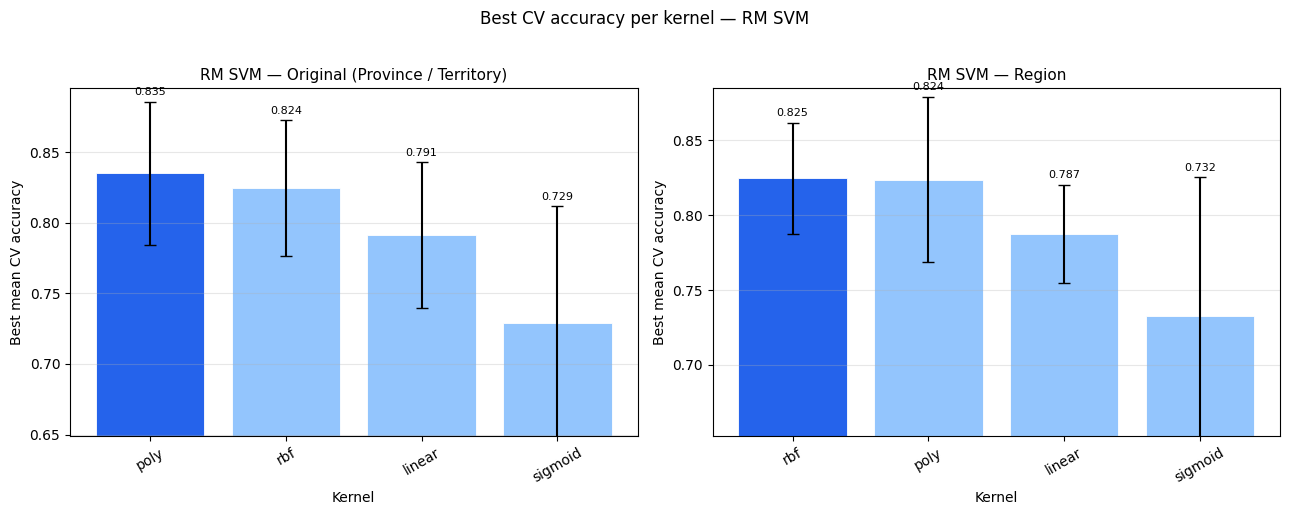

In [10]:
bpk_orig   = best_per_kernel(search_orig['results_df'])
bpk_region = best_per_kernel(search_region['results_df'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, bpk, title in zip(
    axes,
    [bpk_orig, bpk_region],
    ['Original (Province / Territory)', 'Region'],
):
    colors = ['#2563eb' if i == 0 else '#93c5fd' for i in range(len(bpk))]
    bars = ax.bar(bpk['kernel'], bpk['mean_cv'],
                  yerr=bpk['std_cv'], capsize=4,
                  color=colors, edgecolor='white', linewidth=0.6)
    ax.set_title(f'RM SVM — {title}', fontsize=11)
    ax.set_xlabel('Kernel')
    ax.set_ylabel('Best mean CV accuracy')
    ax.set_ylim(
        max(0, bpk['mean_cv'].min() - 0.08),
        min(1, bpk['mean_cv'].max() + 0.06),
    )
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, bpk['mean_cv']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + bpk['std_cv'].iloc[list(bpk['mean_cv']).index(val)] + 0.003,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8,
        )

plt.suptitle('Best CV accuracy per kernel — RM SVM', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8. Learning curves

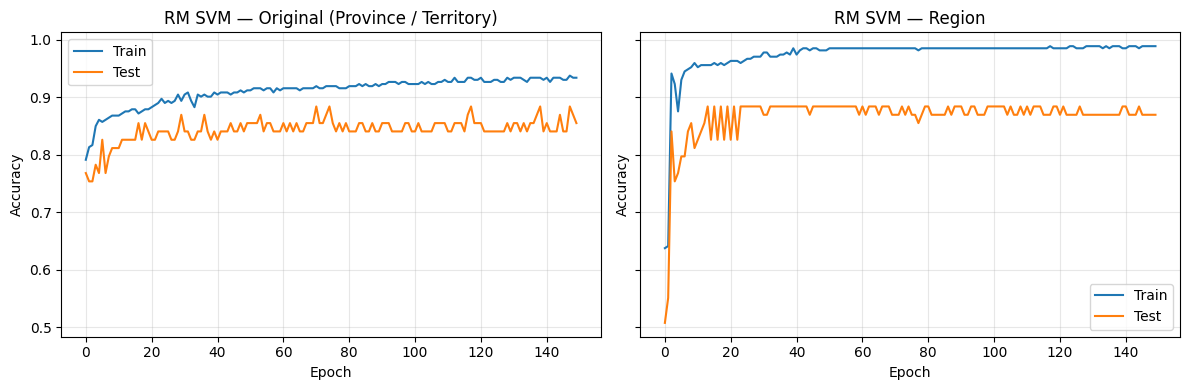

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, fit, title in zip(
    axes,
    [fit_orig, fit_region],
    ['Original (Province / Territory)', 'Region'],
):
    ax.plot(fit['train_acc_history'], label='Train')
    ax.plot(fit['test_acc_history'],  label='Test')
    ax.set_title(f'RM SVM — {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()